# ✨Evaluating spectral reflectance separability✨

This notebook can be used to evaluate spectral separability of point-source spectra using three methods: Hierarchical Cluster Analysis, Spectral Angle Classification, and Random Forest Classification.

## __________________________________________________________________________________________________________________________________________________________
##
## 🔨 Set-up 
Importing modules and data

In [1]:
# Import required scripts
import numpy as np
import pandas as pd
import pvclust
import matplotlib.pyplot as plt
import seaborn as sns
import speca.visualizing as sv
import auxiliary.tools as aux
import speca.spectral_angle_method as sam
import speca.random_forest as rfc
import speca.pca_decomposition as pca
import speca.linear_discrimination as sld

In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

In [43]:
# Import prepared spectra and labels
spectra = pd.read_csv("data/processed/prepped_data_fullres.csv", index_col= 0)
labels = pd.read_csv("data/labels_prepped.csv", index_col = 0)
start_nm = 0
end_nm = len(spectra.columns)

In [44]:
# Check out the first rows and columns of your data/labels
print(spectra.iloc[:5, :5])
print(labels.head())
print(f"First band is: {spectra.columns[0]}")
print(f"Last band is: {spectra.columns[-1]}")
print(f"Band count is: {end_nm}")

          460       461       462       463       464
244  0.245576  0.250073  0.243279  0.238045  0.241237
246  0.190291  0.192652  0.188201  0.184518  0.185922
291  0.087813  0.089224  0.087212  0.086344  0.088979
290  0.066621  0.068829  0.066315  0.064657  0.066447
289  0.187630  0.190945  0.188968  0.187218  0.188860
       Class     setup         site    ko   kom  kbom          bom kbrgm
244  undaria  handheld  new_zealand  kelp  kelp  kelp  brown_algae  kelp
246  undaria  handheld  new_zealand  kelp  kelp  kelp  brown_algae  kelp
291  undaria  handheld     tasmania  kelp  kelp  kelp  brown_algae  kelp
290  undaria  handheld     tasmania  kelp  kelp  kelp  brown_algae  kelp
289  undaria  handheld     tasmania  kelp  kelp  kelp  brown_algae  kelp
First band is: 460
Last band is: 925
Band count is: 466


## __________________________________________________________________________________________________________________________________________________________
##
## 📈 Visualise

This section runs the plotting class using the already defined parameters from preprocessing. Spectra to plot are defined by the user by target types and collection site.

In [25]:
# Initialize visualizer with existing parameters
vizer = sv.Visualizer(spectra, 
                      labels, 
                      start_nm, 
                      end_nm)

# Calculate class statistics for plotting
vizer.class_stats(grouping="Class", 
                  plot_by_site = True)

### Chose spectra to plot

Search words below defines what target types you want to plot. Search sites is optional, but will let you chose to plot spectra from only the specified site(s). The mode parameter can be `any` or `all` to indicate if all of the search terms need to be met or if all must be found to be returned.

In [ ]:
# Define search terms
search_words = ['scytosiphon']
search_sites = []
mode = any
labels["Class"].unique()

In [ ]:
# Run the plotter
vizer.plot_search_terms(search_words = search_words,
                        mode = any,
                        search_sites = search_sites,
                        save_plot= True, 
                        vbars = [55, 85, 115, 140, 185,])

## __________________________________________________________________________________________________________________________________________________________
##
##  🔺Hierarchical Cluster Analysis 🔺
This section uses the pvclust adaptation for Python to run an HCA on the prepared spectra. An optional class means dataset is also calculated for clustering means. 

In [32]:
# Calculate class means for clustering
class_means = aux.calc_class_averages(spectra,
                                      labels,
                                      labels_col="Class",
                                      average_by_site= True)

# Individually label spectra by class-site for clustering
comp_labels = aux.make_compound_labels(labels, ["Class", "site"])
cs_spectra = spectra.set_index(comp_labels)

In [ ]:
# Chose data to cluster
#clust_data = class_means
clust_data = cs_spectra.dropna(axis = 1, how = 'any')

# Perform clustering
pv = pvclust.PvClust(clust_data.T, method = "ward", metric = "euclidean", nboot = 1000, parallel = True)

In [ ]:
# Plot dendrogram
pv.plot(labels= clust_data.index.to_list())
plt.savefig("./plots/pvclust/dendrogram_kelp-sites.svg")

In [ ]:
# Plot clustering standard errors
pv.seplot(pvalue= "AU", annotate=True)

## __________________________________________________________________________________________________________________________________________________________
##
## 📐 Spectral Angle Method
This section runs an adaptation of the conventional spectral angle mapper to be applied to point-source reflectance data.

In [36]:
# Start an instance of the SAM class
sa = sam.SAM(spectra, labels, "Class", by_site = False)

In [ ]:
# Run the chain module to perform all SAM steps
sa.sam_chain()

## __________________________________________________________________________________________________________________________________________________________
##
## 🌲🌳 Random Forest 🌳🌲

This section implements a random forest classifier on the spectra. It includes:
- PCA decomposition
- N-comps determination for PCA
- Hyperparameter grid search
- Random Forest classification

In [45]:
# Extract PCA components
decomposed, ev_ratio, ev, components = pca.run_pca(spectra, n_comps=min(20, len(spectra.columns)))

In [46]:
components_df = pd.DataFrame(components)
components_df.to_csv("ASD_PCA_components.csv")
del components_df

#### Determine number of components to keep

In [7]:
# Check recommended components with elbow and kaiser methods
elbow = pca.find_elbow(ev_ratio)
print(f"Elbow found at: {elbow+1} components \n  Explained variance ratio: {ev_ratio[elbow]} \n  Total explained variance: {np.sum(ev_ratio[:elbow+1])}")

kaiser = pca.find_kaiser(ev)
print(f"Kaiser value found at: {kaiser+1} components \n  Explained variance ratio: {ev_ratio[kaiser]} \n  Total explained variance: {np.sum(ev_ratio[:kaiser+1])}")

Elbow found at: 3 components 
  Explained variance ratio: 0.034006156751250204 
  Total explained variance: 0.993431003046942
Kaiser value found at: 1 components 
  Explained variance ratio: 0.7657622017438757 
  Total explained variance: 0.7657622017438757


In [15]:
# Check number of components with accuracy based methods
# Run  a set of RFCs to use for accuracy estimates
accub = pca.NCompsByAccuracy(spectra, labels, labels_col = "ko")
accub.calc_mean_accuracies(max_n = components.shape[1])

In [16]:
# Evaluate proximity and marginal gains from RFC runs
proximity = accub.find_n_by_max_proximity()
margin = accub.find_n_by_margin()

# View results
print(proximity)
print(margin)

{'n': 5, 'Accuracy at n': 0.9153846153846156, 'Max Accuracy': 0.9153846153846156}
{'n': 3, 'Accuracy at n': 0.8357264957264958, 'Accuracy at n+1': 0.8647863247863248}


You now have four suggestions for the number of components to use in subsequent analysis:
- Two based on dataset variance (elbow, kaiser) 
- Two based on preliminary classification accuracy (margin, proximity). 

The best suited option is subjective and will affect:
- data volume 💼
- computational requirements 💻 
- processing time ⏳
- and accuracy 📍

#### Perform the Random Forest Classification

In [10]:
# Choose if classifying by site
label_by_site = False

In [17]:
# Make labels accordingly 
if label_by_site:
    comp_labels = aux.make_compound_labels(labels, ["Class", "site"])
    labels_to_use = comp_labels
else:
    labels_to_use = labels["ko"]
    
# View the labels for your data set

labels_to_use.unique()

array(['kelp', 'non_kelp'], dtype=object)

In [18]:
# Initialize a classifer with your chosen number of components
forest = rfc.RandoForest(components[:, :proximity['n']], labels_to_use, runs = 10000) 

In [19]:
# Run a grid search

# OPTIONAL: Define the parameters for the grid search, otherwise uses defaults
params_dt = {'min_samples_split': [2,3],
'n_estimators': [100], #50, 60, 75, 90, 105, 150, 200],
'max_depth': [20, 30, 40, 50, None],
'max_leaf_nodes': [40, 50, 60]
}

# Perform search and view results
forest.grid_search(parameters=params_dt)

 Best parameters: {'max_depth': 50, 'max_leaf_nodes': 40, 'min_samples_split': 2, 'n_estimators': 100}
 Best score: 0.7798940178278234


In [20]:
# Calculate aggregate results over many random forest runs
forest.hyperparams = {
    'min_samples_split':2,
    'n_estimators': 100,
    'max_depth': 50,
    'max_leaf_nodes': 40
    }
forest.many_rfc_runs()

Mean accuracy for ko is 0.9116743589743591.
Mean recall is 0.9116743589743591.
Mean precision is 0.9126365894729681.
Mean balanced accuracy  is 0.8695657467532466.
Mean F1 score is 0.8853229568020359.


#### Plot the RFC confusion matrix

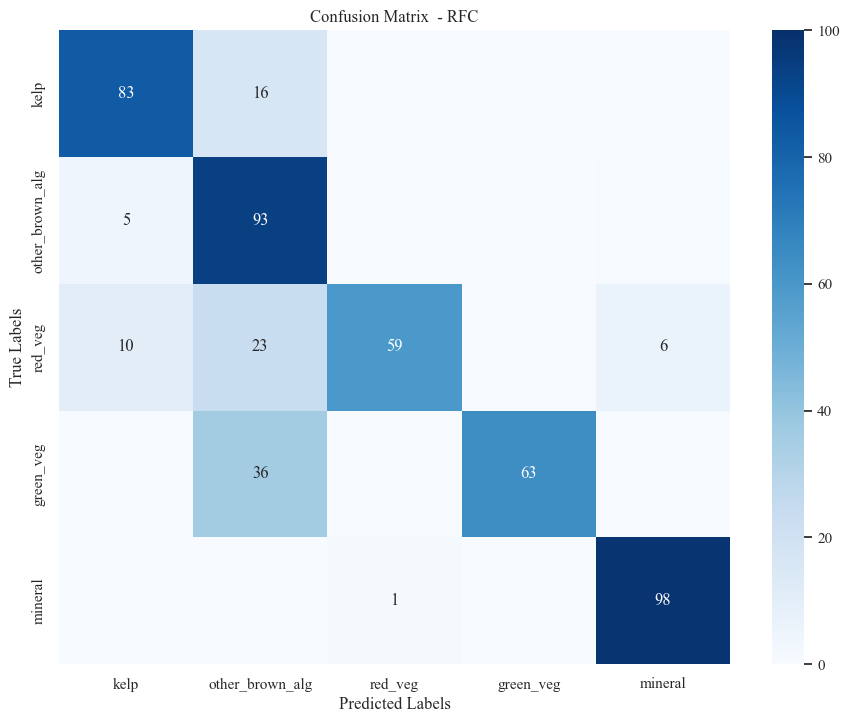

In [18]:
forest.plot_cm()

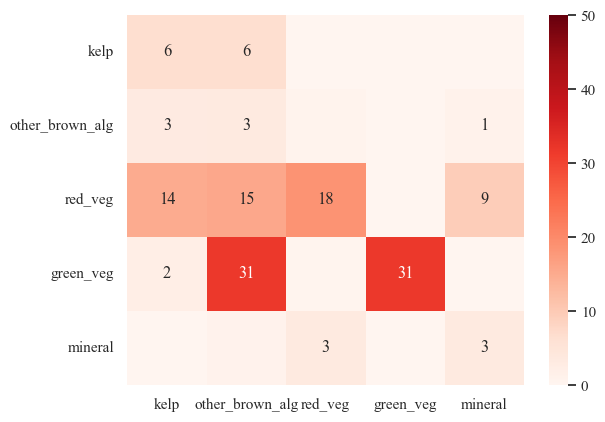

In [19]:
# Plot the standard deviation matrix of confusion errors
df = pd.DataFrame(np.std(forest.rfc_results["cm"], axis = 0))
df_masked = df.map(lambda v: str(int(v*100)) if int(v*100) > 0 else "")

sns.heatmap(df*100, cmap = "Reds", annot = df_masked, fmt = "s",  vmin = 0, vmax = 50, xticklabels = labels_to_use.unique(), yticklabels = labels_to_use.unique())

# Save figure
plt.savefig("./plots/rfc/asd_kbrgm_std_10000a.svg")

In [20]:
imps = forest.rfc_results["importances"]
imps = pd.DataFrame(imps)
imps.mean(axis = 0)

0    0.177379
1    0.123751
2    0.091610
3    0.136477
4    0.093037
5    0.132515
6    0.245232
dtype: float64

## __________________________________________________________________________________________________________________________________________________________
##
## 💥Linear discriminant analysis (LDA) 
Aggregate the result of n runs of a linear discriminant analysis with sample re-division

In [82]:
# Make placeholder for results
f1_scores = []
cms = []

# Run linear discrimination for many iterations
for i in range(10000):
    linear = sld.LDA_classify(spectra, labels_to_use)
    f1_scores.append(linear["f1_score"])
    cms.append(linear["cm"])

In [ ]:
# Get mean result
print(f" The mean F1 score is : {round(np.mean(f1_scores), 4)}")

In [ ]:
# Plot the mean confusion matrix with F1 scores as percents
meanies = pd.DataFrame(np.array(cms).mean(axis=0))

meanies_masked = meanies.map(lambda v: str(int(v*100)) if int(v*100) > 0 else "")

sns.heatmap(meanies*100, annot = meanies_masked, fmt = "s", cmap = "Blues", xticklabels = labels_to_use.unique(), yticklabels = labels_to_use.unique(), vmin = 0, vmax = 100)

# Save figure to file
plt.savefig("./plots/lda/plot_confmat.svg")

In [ ]:
# Plot standard dveiation of confusion errors
devies = pd.DataFrame(np.array(cms).std(axis=0))
devies_masked = df.map(lambda v: str(int(v*100)) if int(v*100) > 0 else "")

sns.heatmap(devies*100, cmap = "Reds", annot = devies_masked, fmt = "s",  vmin = 0, vmax = 50, xticklabels = labels_to_use.unique(), yticklabels = labels_to_use.unique())

# Save output to file
plt.savefig("./plots/lda/plot_std.svg")

In [ ]:
# Transform the spectra into their LDA components
decomp_spectra = sld.LDA_transform(spectra, labels_to_use, test_size=0.3)

In [ ]:
# Plot  2 or 3 LDA components
sld.LDA_plot_comps(decomp_spectra, labels_to_use, components = [0,2,1])

plt.savefig("plots/lda/plot_3comps.svg")